You are a data analyst working for a tech company closely monitoring the AI tools market. You want to understand the evolving popularity of three major AI tools, ChatGPT, Gemini, and Microsoft Copilot, and identify which tool is gaining the most traction and how they compare over time.

<br/>

<div align="center">
  <img src="ai_tools.jpg" width="420" alt="ChatGPT, Copilot, and Gemini"/>
</div>

<br/>

You'll work with real-world time series data that captures the global interest in these tools over several weeks. Your goal is to analyze this data, uncover patterns, and provide actionable insights to help your company make informed decisions. This might include determining where to focus marketing efforts, predicting future trends, or identifying potential areas for improvement.

Are you ready to help your company stay ahead of the curve in the competitive AI tools market? Let's get started!

### The Data

The Google Trends data is available as a CSV file `ai_tools_comparison.csv`.

The data contains the number of worldwide searches for ChatGPT, Gemini, and Microsoft Copilot over the past 12 months as of September 2024.

<!--- Link to query: https://trends.google.com/trends/explore?q=chatgpt,gemini,%2Fg%2F11tsqm45vd&hl=en-US -->

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
trends = pd.read_csv('ai_tools_comparison.csv')

# Inspect the data
trends.head()

,week,chatgpt,gemini,microsoft_copilot
0,2023-08-27,56,3,1
1,2023-09-03,56,3,1
2,2023-09-10,63,3,1
3,2023-09-17,64,3,1
4,2023-09-24,66,3,1


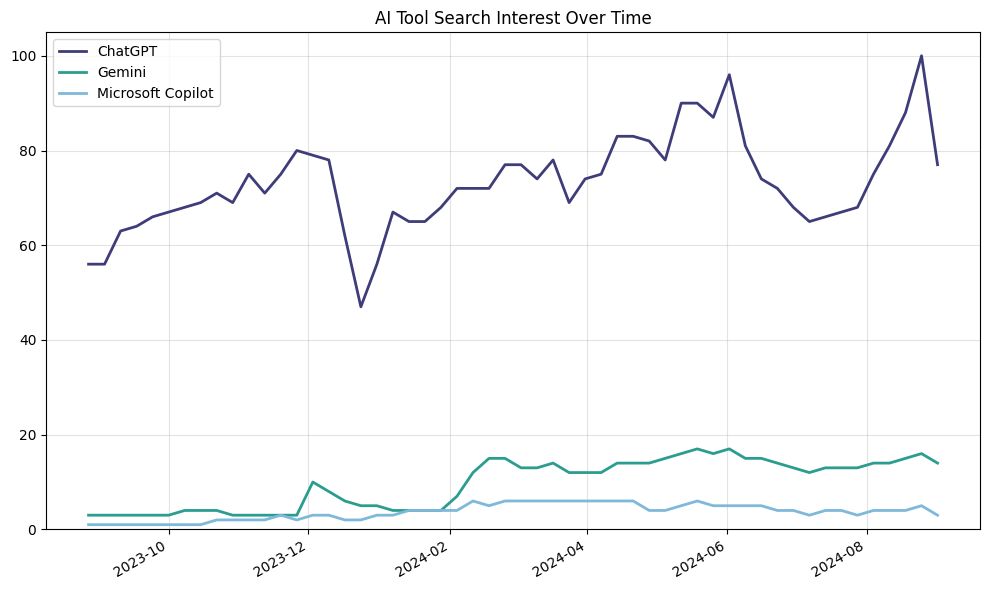

most_consistent_tool = 'chatgpt'
gpt_dip = 'September 2024'
best_month = 'May'


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load the data
trends = pd.read_csv('ai_tools_comparison.csv')

# Convert week to datetime and set as index
trends['week'] = pd.to_datetime(trends['week'])
trends.set_index('week', inplace=True)

# We can calculate the total growth (last value - first value)
growth = trends.iloc[-1] - trends.iloc[0]
most_consistent_tool = growth.idxmax()

# Visualization and finding the ChatGPT dip
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(trends.index, trends['chatgpt'], label='ChatGPT', color='#3f3c7a', linewidth=2)
ax.plot(trends.index, trends['gemini'], label='Gemini', color='#2a9d8f', linewidth=2)
ax.plot(trends.index, trends['microsoft_copilot'], label='Microsoft Copilot', color='#7eb8da', linewidth=2)
ax.set_title('AI Tool Search Interest Over Time')
ax.legend()
ax.grid(True, alpha=0.35)
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Find the largest week-over-week decline for ChatGPT
trends['gpt_diff'] = trends['chatgpt'].diff()
largest_decline_date = trends['gpt_diff'].idxmin()
gpt_dip = largest_decline_date.strftime('%B %Y')

# Seasonal breakdown (monthly averages)
monthly_avg = trends[['chatgpt', 'gemini', 'microsoft_copilot']].resample('ME').mean()

# Calculate average across all tools for each month
monthly_avg['total_avg'] = monthly_avg.mean(axis=1)
best_month = monthly_avg['total_avg'].idxmax().strftime('%B')

# Output results for variables
print(f"most_consistent_tool = '{most_consistent_tool}'")
print(f"gpt_dip = '{gpt_dip}'")
print(f"best_month = '{best_month}'")